In [1]:
# Load the results from the sweeps (files in ./results/) and visualize performance over hyperparameters
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
from IPython.display import display, HTML

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('notebook')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14

## Load data

In [ ]:
# Set the results directory path
out_dir = './results/sim_sweep3'
results_dir = './results/sim_sweep3_seed*.csv'
#results_dir = './results/sim_sweep*_adapter*.csv'

# Find all CSV files in the results directory
csv_files = glob.glob(results_dir)
print(f"Found {len(csv_files)} CSV files in the results directory.")

# Group files by type (train, regression, classification)
train_files = [f for f in csv_files if 'train' in f.lower()]
regression_files = [f for f in csv_files if 'regression' in f.lower()]
classification_files = [f for f in csv_files if 'classification' in f.lower()]
#rank_files = [f for f in csv_files if 'rank' in f.lower()]
rank_files = [f for f in csv_files if 'analysis' in f.lower()]
hyperparams_files = [f for f in csv_files if 'hyperparams' in f.lower()]

print(f"Train files: {len(train_files)}")
print(f"Regression files: {len(regression_files)}")
print(f"Classification files: {len(classification_files)}")
print(f"Rank files: {len(rank_files)}")
print(f"Hyperparams files: {len(hyperparams_files)}")

Found 15 CSV files in the results directory.
Train files: 3
Regression files: 3
Classification files: 3
Rank files: 3
Hyperparams files: 3


In [3]:
# Load all the regression data
regression_dfs = []
for file in regression_files:
    df = pd.read_csv(file)
    # Add filename as a column for tracking
    df['source_file'] = os.path.basename(file)
    regression_dfs.append(df)

# Combine all regression data
if regression_dfs:
    regression_df = pd.concat(regression_dfs, ignore_index=True)
    print(f"Loaded regression data: {regression_df.shape[0]} rows, {regression_df.shape[1]} columns")
    display(regression_df.head())
else:
    regression_df = None
    print("No regression data found.")

Loaded regression data: 588 rows, 6 columns


,name,r2_mean,r2_std,run_iter,seed,source_file
0,Zm1,0.865958,0.068711,0,346,sim_sweep3_seed346_regression.csv
1,Zs1,0.853330,0.143885,0,346,sim_sweep3_seed346_regression.csv
2,(Zm+Zs)1,0.927921,0.051267,0,346,sim_sweep3_seed346_regression.csv
3,Zm2,0.606981,0.251555,0,346,sim_sweep3_seed346_regression.csv
4,Zs2,0.612594,0.210982,0,346,sim_sweep3_seed346_regression.csv


In [4]:
# Load all the classification data
classification_dfs = []
for file in classification_files:
    df = pd.read_csv(file)
    # Add filename as a column for tracking
    df['source_file'] = os.path.basename(file)
    classification_dfs.append(df)

# Combine all classification data
if classification_dfs:
    classification_df = pd.concat(classification_dfs, ignore_index=True)
    print(f"Loaded classification data: {classification_df.shape[0]} rows, {classification_df.shape[1]} columns")
    display(classification_df.head())
else:
    classification_df = None
    print("No classification data found.")

Loaded classification data: 392 rows, 9 columns


,name,accuracy,precision,recall,f1,roc_auc,run_iter,seed,source_file
0,Zs1,0.973,0.964676,0.982,0.973191,0.973,0,0,sim_sweep3_seed0_classification.csv
1,Zs2,0.910,0.893848,0.932,0.912122,0.910,0,0,sim_sweep3_seed0_classification.csv
2,Zm1,0.955,0.965193,0.944,0.954240,0.955,0,0,sim_sweep3_seed0_classification.csv
3,Zm2,0.916,0.894089,0.944,0.918287,0.916,0,0,sim_sweep3_seed0_classification.csv
4,Zs1,0.988,0.988157,0.988,0.987958,0.988,1,0,sim_sweep3_seed0_classification.csv


In [5]:
# same for rank
rank_dfs = []
for file in rank_files:
    df = pd.read_csv(file)
    # Add filename as a column for tracking
    df['source_file'] = os.path.basename(file)
    rank_dfs.append(df)

# Combine all rank data
if rank_dfs:
    rank_df = pd.concat(rank_dfs, ignore_index=True)
    print(f"Loaded rank data: {rank_df.shape[0]} rows, {rank_df.shape[1]} columns")
    display(rank_df.head())
else:
    rank_df = None
    print("No rank data found.")

Loaded rank data: 588 rows, 6 columns


,name,metric,value,run_iter,seed,source_file
0,R_s-R_m1,correlation,0.083072,0,0,sim_sweep3_seed0_analysis.csv
1,R_s-R_m2,correlation,-0.001943,0,0,sim_sweep3_seed0_analysis.csv
2,R_m1-R_m2,correlation,-0.200048,0,0,sim_sweep3_seed0_analysis.csv
3,R_s,rank,4.000000,0,0,sim_sweep3_seed0_analysis.csv
4,R_m1,rank,4.000000,0,0,sim_sweep3_seed0_analysis.csv


In [6]:
train_dfs = []
for file in train_files:
    df = pd.read_csv(file)
    # Add filename as a column for tracking
    #df['source_file'] = os.path.basename(file)
    #df['seed'] = file.split('_seed')[-1].split('_')[0]
    train_dfs.append(df)
# Combine all train data
if train_dfs:
    train_df = pd.concat(train_dfs, ignore_index=True)
    print(f"Loaded train data: {train_df.shape[0]} rows, {train_df.shape[1]} columns")
    #cols_for_name = ['batch_size', 'learning_rate', 'lr_annealing', 'weight_decay', 'specific_rank', 'shared_rank', 'seed']
    #train_df['model_name'] = train_df[cols_for_name].astype(str).agg('-'.join, axis=1)
    display(train_df.head())
else:
    train_df = None
    print("No train data found.")

Loaded train data: 16232 rows, 7 columns


,Shared Loss,Orthogonal Loss,Mutual Info Loss,stage,epoch,run_iter,seed
0,0.042194,0.646781,9.352798,shared,0,0,346
1,0.037004,0.646717,9.311204,shared,1,0,346
2,0.037388,0.646658,9.265385,shared,2,0,346
3,0.036526,0.646597,9.315120,shared,3,0,346
4,0.042026,0.646530,9.267235,shared,4,0,346


In [7]:
hyperparams_dfs = []
for file in hyperparams_files:
    df = pd.read_csv(file)
    # Add filename as a column for tracking
    #df['source_file'] = os.path.basename(file)
    hyperparams_dfs.append(df)
# Combine all hyperparams data
if hyperparams_dfs:
    hyperparams_df = pd.concat(hyperparams_dfs, ignore_index=True)
    print(f"Loaded hyperparams data: {hyperparams_df.shape[0]} rows, {hyperparams_df.shape[1]} columns")
    display(hyperparams_df.head())
else:
    hyperparams_df = None
    print("No hyperparams data found.")

Loaded hyperparams data: 98 rows, 18 columns


,batch_size,learning_rate,weight_decay,weight_init,lr_annealing,n_specific_rank,n_shared_rank,patience1,patience2,min_improvement_ratio1,min_improvement_ratio2,max_epochs,staging,pruning,z_ortho_loss,model_number,seed,stopping_criterion
0,128,0.00001,0.0001,xavier_uniform,cosine,4,4,5,5,0.001,0.001,1000,True,True,False,0,346,improvement
1,128,0.00001,0.0001,xavier_uniform,cosine,4,4,5,5,0.001,0.001,1000,True,True,False,0,346,improvement
2,128,0.00001,0.0001,xavier_uniform,cosine,4,4,5,5,0.001,0.001,1000,True,True,False,0,346,improvement
3,128,0.00001,0.0001,xavier_uniform,cosine,4,4,5,5,0.001,0.001,1000,False,True,False,1,346,improvement
4,128,0.00001,0.0001,xavier_uniform,linear,4,4,5,5,0.001,0.001,1000,True,True,False,2,346,improvement


## Functions

In [8]:
def plot_score_by_hyperparam(df, param, metric='r2_mean', metric_type='column'):
    if df is None:
        print("No data available.")
        return
    
    if param not in df.columns or (metric not in df.columns and metric_type == 'column'):
        print(f"Either {param} or {metric} not found in data.")
        return
    elif param not in df.columns or (metric_type == 'value' and metric not in df['metric'].values):
        print(f"Either {param} or {metric} not found in data.")
        return
    elif metric_type not in ['column', 'value']:
        print(f"Invalid metric type: {metric_type}. Use 'column' or 'value'.")
        return
    
    # Check if there's more than one unique value for this hyperparameter
    unique_values = df[param].unique()
    if len(unique_values) <= 1:
        print(f"Skipping plots for {param} because there is only one unique value: {unique_values}")
        return
    
    # Create one bar plot for component performances grouped by the hyperparameter
    plt.figure(figsize=(8, 3))
    
    if metric_type == 'column':
        sns.barplot(x='name', y=metric, hue=param, data=df,
                    errorbar='se', palette='muted', capsize=0.1, alpha=0.8)
        # set y limits to min and max of the metric
        #plt.ylim(df[metric].min() - 0.1, df[metric].max() + 0.1)
    else:
        df = df[df['metric'] == metric]
        sns.barplot(x='name', y='value', hue=param, data=df,
                    errorbar='se', palette='muted', capsize=0.1, alpha=0.8)
        # set y limits to min and max of the metric
        #plt.ylim(df['value'].min() - 0.1, df['value'].max() + 0.1)
    
    plt.title(f'Average Score by {param}')
    plt.ylabel(f'Score ({metric})')
    plt.xlabel('Representation Component')
    plt.xticks(rotation=45)
    plt.legend(title=param, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

## Learning curves

In [9]:
# add the hyperparams to the train data
hyperparams = hyperparams_df.columns[:-2].tolist()

train_dfs_hyperparams = []
for run_iter in train_df['run_iter'].unique():
    # get the hyperparams for this run_iter
    hyperparams_run_iter = hyperparams_df[hyperparams_df['model_number'] == run_iter].iloc[0][hyperparams].to_dict()
    # add the hyperparams to the train data
    train_dfs_hyperparams.append(train_df[train_df['run_iter'] == run_iter].assign(**hyperparams_run_iter))
train_df_hyperparams = pd.concat(train_dfs_hyperparams, ignore_index=True)
display(train_df_hyperparams.head())

,Shared Loss,Orthogonal Loss,Mutual Info Loss,stage,epoch,run_iter,seed,batch_size,learning_rate,weight_decay,...,n_shared_rank,patience1,patience2,min_improvement_ratio1,min_improvement_ratio2,max_epochs,staging,pruning,z_ortho_loss,model_number
0,0.042194,0.646781,9.352798,shared,0,0,346,128,0.00001,0.0001,...,4,5,5,0.001,0.001,1000,True,True,False,0
1,0.037004,0.646717,9.311204,shared,1,0,346,128,0.00001,0.0001,...,4,5,5,0.001,0.001,1000,True,True,False,0
2,0.037388,0.646658,9.265385,shared,2,0,346,128,0.00001,0.0001,...,4,5,5,0.001,0.001,1000,True,True,False,0
3,0.036526,0.646597,9.315120,shared,3,0,346,128,0.00001,0.0001,...,4,5,5,0.001,0.001,1000,True,True,False,0
4,0.042026,0.646530,9.267235,shared,4,0,346,128,0.00001,0.0001,...,4,5,5,0.001,0.001,1000,True,True,False,0


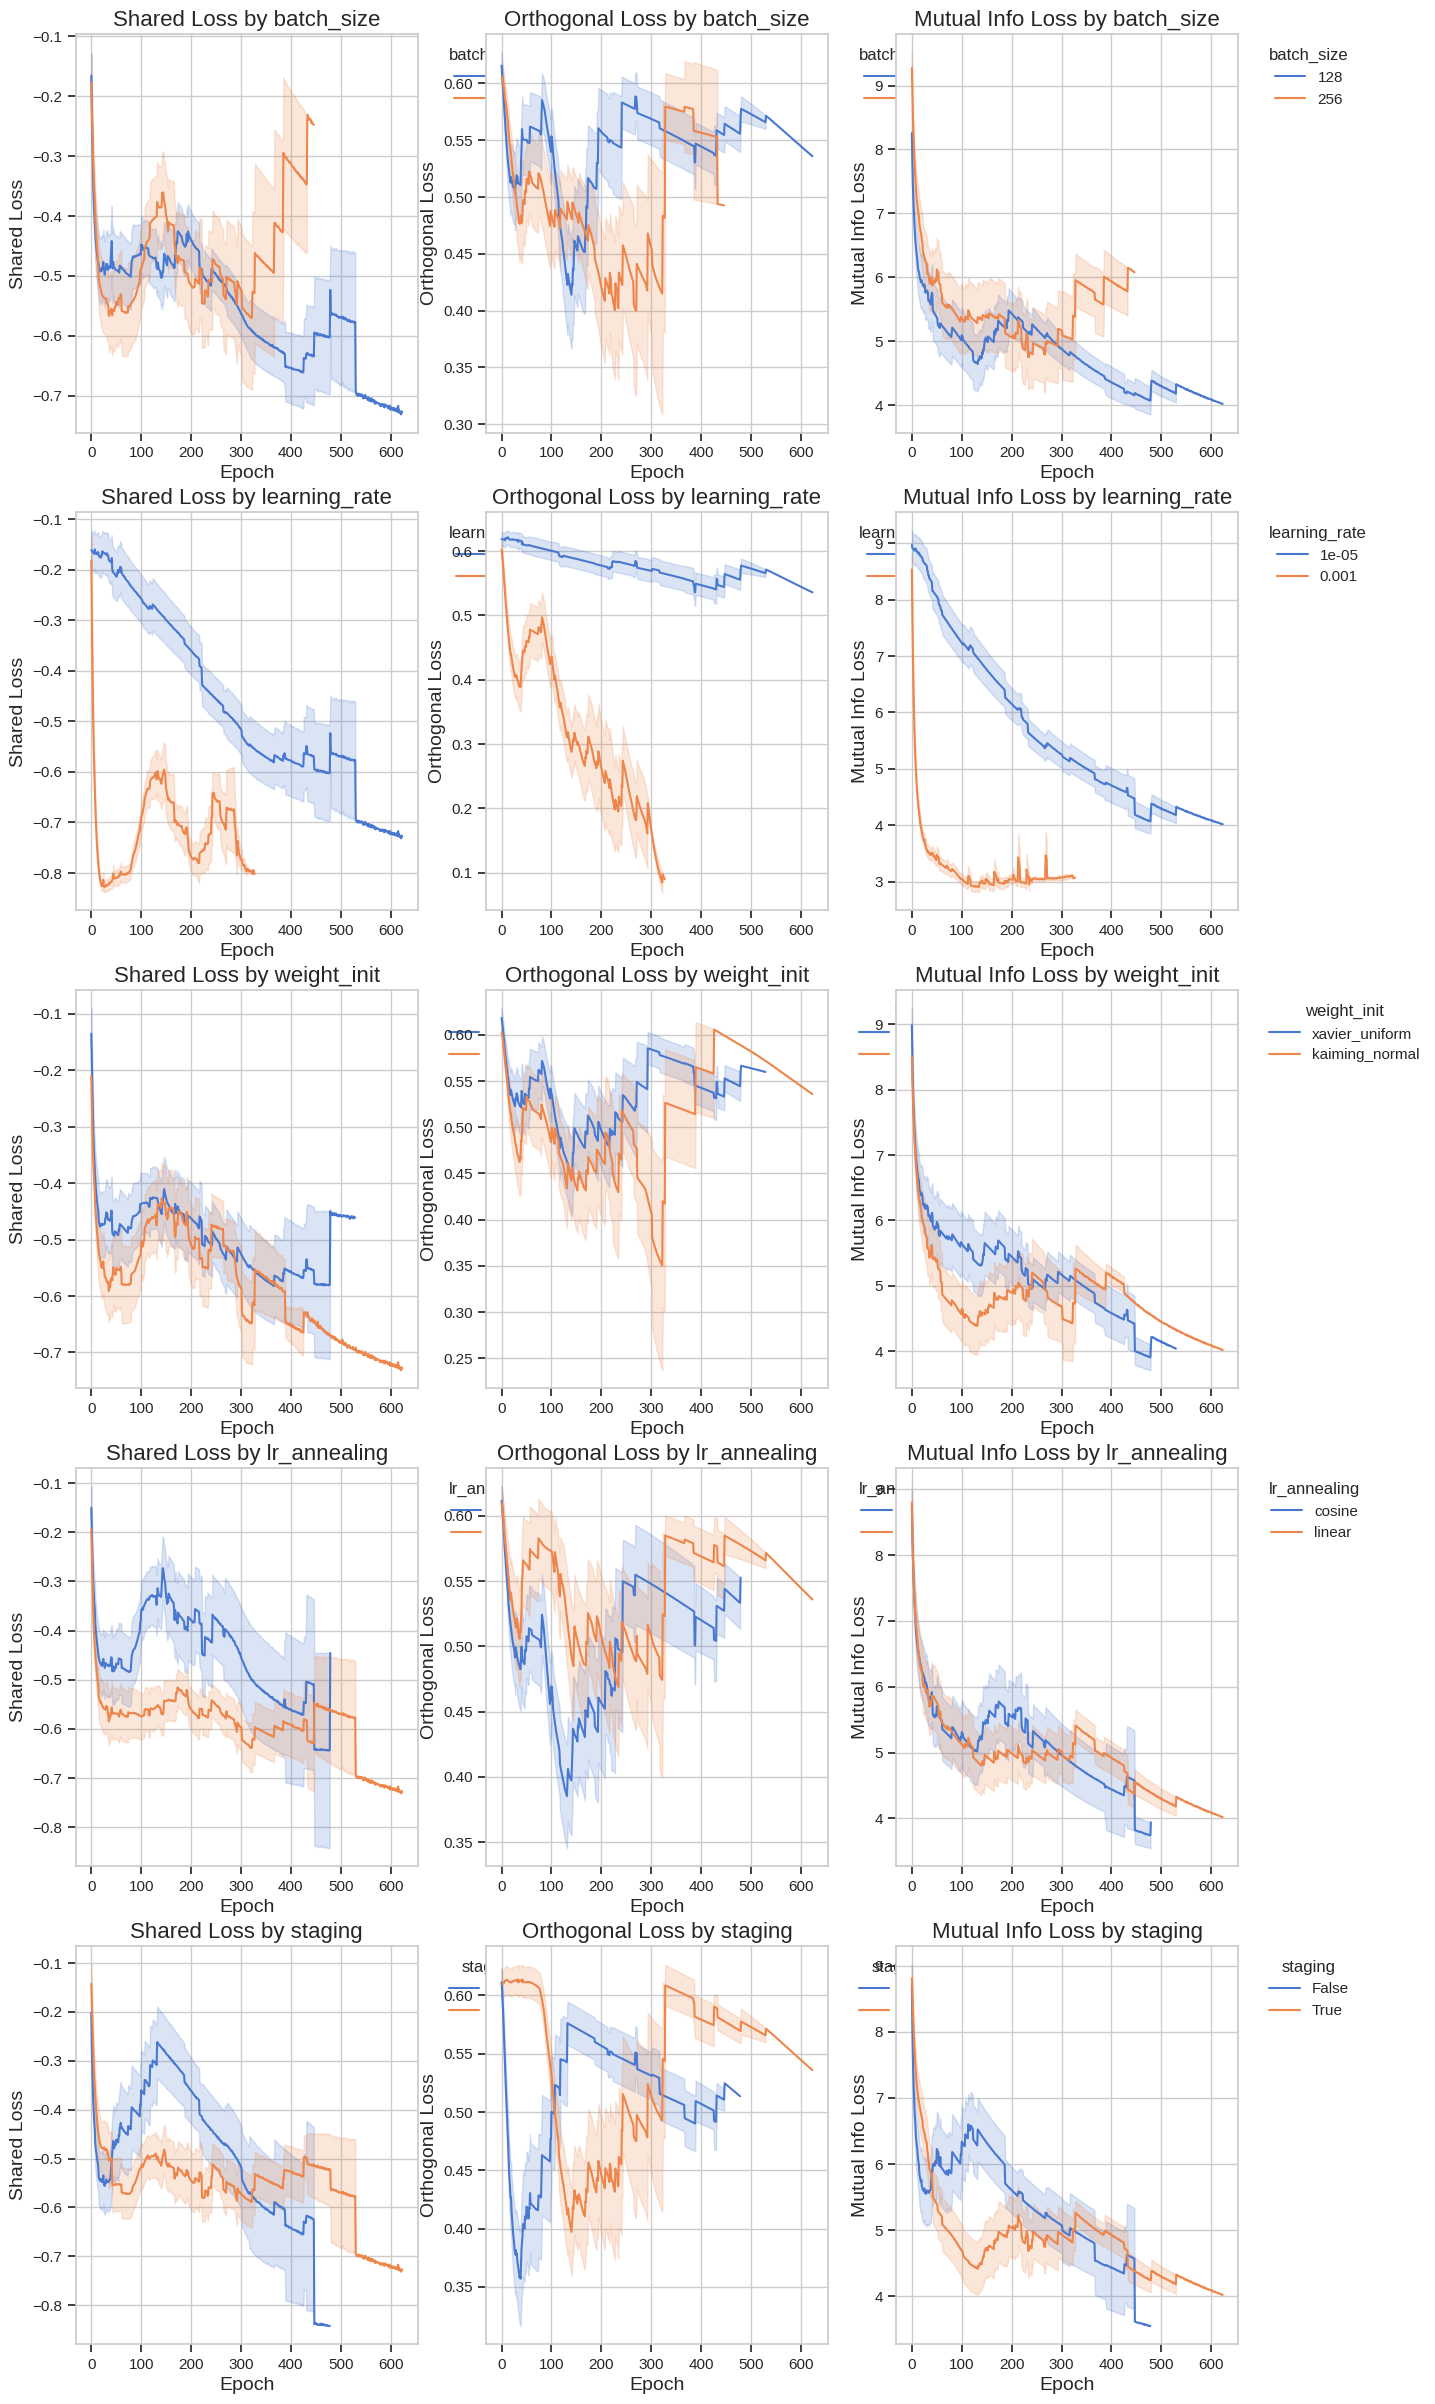

In [10]:
loss_columns = ['Shared Loss', 'Orthogonal Loss', 'Mutual Info Loss']
#loss_columns = ['Sparsity Loss', 'Orthogonal Loss', 'Mutual Info Loss']
# filter the hyperparams to only those with more than 1 unique value
hyperparams = [hp for hp in hyperparams if len(train_df_hyperparams[hp].unique()) > 1]
# remove 'model_number' and 'run_iter' from the hyperparams
hyperparams = [hp for hp in hyperparams if hp not in ['model_number', 'run_iter']]

fig, axs = plt.subplots(len(hyperparams), len(loss_columns), figsize=(15,30))

for i in range(len(loss_columns)):
    for j in range(len(hyperparams)):
        sns.lineplot(data=train_df_hyperparams, x='epoch', y=loss_columns[i], ax=axs[j, i], hue=hyperparams[j], palette='muted', errorbar='se')
        axs[j, i].set_title(f'{loss_columns[i]} by {hyperparams[j]}')
        axs[j, i].set_xlabel('Epoch')
        axs[j, i].set_ylabel(loss_columns[i])
        axs[j, i].legend(title=hyperparams[j], bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## Accuracy

In [11]:
# add the hyperparams to the train data
hyperparams = hyperparams_df.columns[:-2].tolist()
hyperparams = [hp for hp in hyperparams if len(train_df_hyperparams[hp].unique()) > 1]
hyperparams = [hp for hp in hyperparams if hp not in ['model_number', 'run_iter']]

class_dfs_hyperparams = []
for run_iter in train_df['run_iter'].unique():
    # get the hyperparams for this run_iter
    hyperparams_run_iter = hyperparams_df[hyperparams_df['model_number'] == run_iter].iloc[0][hyperparams].to_dict()
    # add the hyperparams to the classification data
    class_dfs_hyperparams.append(classification_df[classification_df['run_iter'] == run_iter].assign(**hyperparams_run_iter))
class_df_hyperparams = pd.concat(class_dfs_hyperparams, ignore_index=True)
# filter the hyperparams to only those with more than 1 unique value
hyperparams = [hp for hp in hyperparams if len(train_df_hyperparams[hp].unique()) > 1]
display(class_df_hyperparams.head())

,name,accuracy,precision,recall,f1,roc_auc,run_iter,seed,source_file,batch_size,learning_rate,weight_init,lr_annealing,staging
0,Zs1,0.973,0.964676,0.982,0.973191,0.973,0,0,sim_sweep3_seed0_classification.csv,128,0.00001,xavier_uniform,cosine,True
1,Zs2,0.910,0.893848,0.932,0.912122,0.910,0,0,sim_sweep3_seed0_classification.csv,128,0.00001,xavier_uniform,cosine,True
2,Zm1,0.955,0.965193,0.944,0.954240,0.955,0,0,sim_sweep3_seed0_classification.csv,128,0.00001,xavier_uniform,cosine,True
3,Zm2,0.916,0.894089,0.944,0.918287,0.916,0,0,sim_sweep3_seed0_classification.csv,128,0.00001,xavier_uniform,cosine,True
4,Zs1,0.980,0.984037,0.976,0.979856,0.980,0,42,sim_sweep3_seed42_classification.csv,128,0.00001,xavier_uniform,cosine,True


/tmp/ipykernel_1219509/4076022226.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='name', y=metric, data=classification_df, errorbar='se', palette='muted', capsize=0.1, alpha=0.8)


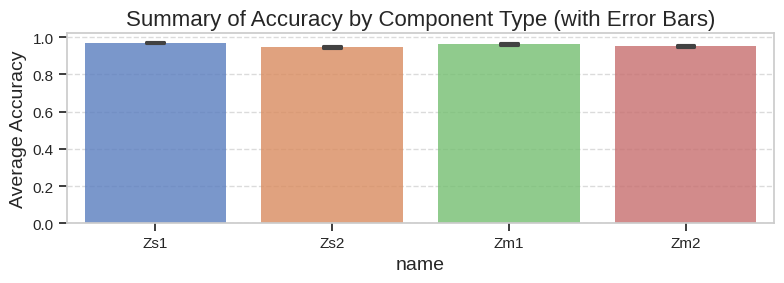


Summary of Accuracy by Component:
Zs1: 0.9691 ± 0.0278 (se: 0.0014)
Zm1: 0.9636 ± 0.0320 (se: 0.0016)
Zm2: 0.9526 ± 0.0487 (se: 0.0025)
Zs2: 0.9468 ± 0.0523 (se: 0.0026)


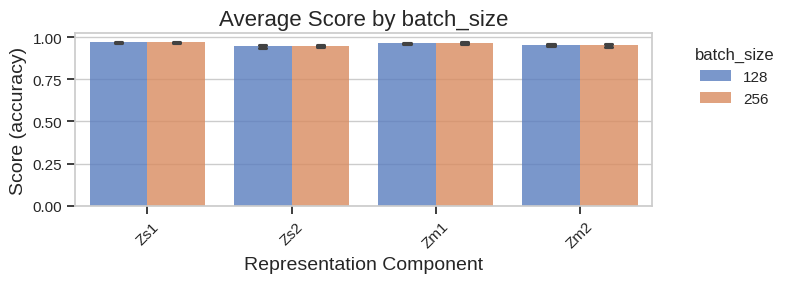

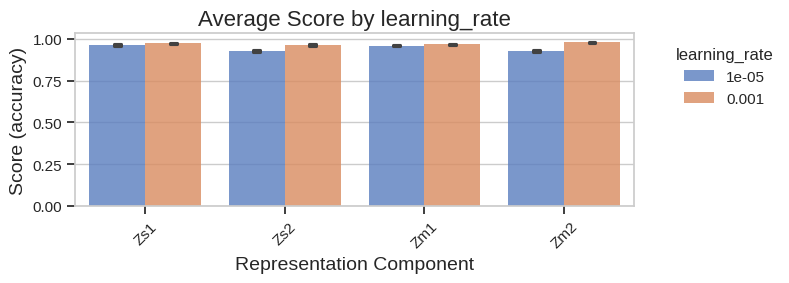

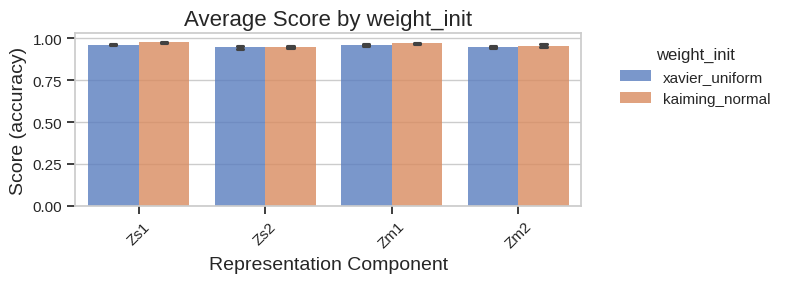

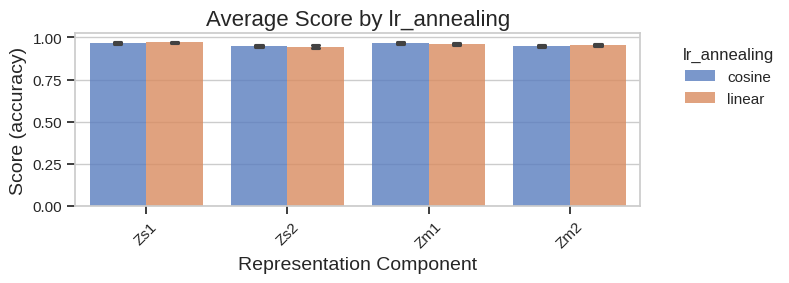

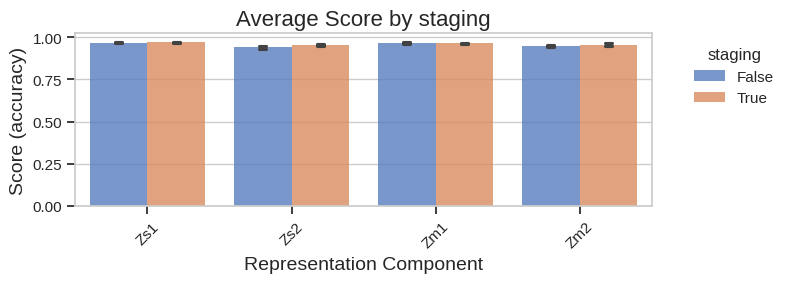

In [12]:
# Visualize classification performance by hyperparameters

# Create a summary bar plot of classification metrics by component type with error bars
if classification_df is not None:
    #metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
    metrics = ['accuracy']
    available_metrics = [m for m in metrics if m in classification_df.columns]
    
    for metric in available_metrics:
        plt.figure(figsize=(8, 3))
        
        # Group by component name and compute mean and std
        summary_data = classification_df.groupby('name')[metric].agg(['mean', 'std']).reset_index()
        
        # Sort by mean score for better visualization
        summary_data = summary_data.sort_values('mean', ascending=False)
        
        sns.barplot(x='name', y=metric, data=classification_df, errorbar='se', palette='muted', capsize=0.1, alpha=0.8)
        
        plt.title(f'Summary of {metric.capitalize()} by Component Type (with Error Bars)')
        plt.ylabel(f'Average {metric.capitalize()}')
        #plt.xticks(range(len(summary_data)), summary_data['name'], rotation=45)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
        
        # Print numerical summary
        print(f"\nSummary of {metric.capitalize()} by Component:")
        for idx, row in summary_data.iterrows():
            print(f"{row['name']}: {row['mean']:.4f} ± {row['std']:.4f} (se: {row['std'] / np.sqrt(len(classification_df)):.4f})")

# Plot for each hyperparameter with multiple unique values
for param in hyperparams:
    plot_score_by_hyperparam(class_df_hyperparams, param, metric='accuracy')

In [38]:
# get the accuracies for each run (average over random seed)
#class_df_hyperparams.groupby(['name', 'batch_size', 'learning_rate', 'weight_init', 'lr_annealing', 'staging']).agg({'accuracy': ['mean', 'std']}).reset_index()
# transform this into wide format for the name
class_df_hyperparams_wide = class_df_hyperparams.pivot_table(index=['batch_size', 'learning_rate', 'weight_init', 'lr_annealing', 'staging', 'seed'], columns='name', values='accuracy').reset_index()
class_df_report = class_df_hyperparams_wide.groupby(['batch_size', 'learning_rate', 'weight_init', 'lr_annealing', 'staging']).agg(['mean', 'std']).reset_index()
# through out columns name and seed
class_df_report.columns = ['_'.join(col).strip() if col[1] != '' else col[0] for col in class_df_report.columns.values]
class_df_report = class_df_report.drop(columns=['seed_mean', 'seed_std'])
# for each row add whether Zm1_mean is greater than Zs1_mean
class_df_report['Zs1_greater_Zm1'] = class_df_report['Zs1_mean'] > class_df_report['Zm1_mean']
class_df_report['Zs2_greater_Zm2'] = class_df_report['Zs2_mean'] > class_df_report['Zm2_mean']
class_df_report['Zs1_greater_Zm2'] = class_df_report['Zs1_mean'] > class_df_report['Zm2_mean']
class_df_report['Zs2_greater_Zm1'] = class_df_report['Zs2_mean'] > class_df_report['Zm1_mean']
class_df_report['Zs_greater_Zm'] = class_df_report['Zs1_greater_Zm1'] & class_df_report['Zs2_greater_Zm2'] & class_df_report['Zs1_greater_Zm2'] & class_df_report['Zs2_greater_Zm1']
# save the report to a csv file
class_df_report.to_csv(out_dir + '_class_report.csv', index=False)

## Predictability

In [13]:
# same for regression
# add the hyperparams to the regression data
hyperparams = hyperparams_df.columns[:-2].tolist()
hyperparams = [hp for hp in hyperparams if len(train_df_hyperparams[hp].unique()) > 1]
hyperparams = [hp for hp in hyperparams if hp not in ['model_number', 'run_iter']]

regression_dfs_hyperparams = []
for run_iter in train_df['run_iter'].unique():
    # get the hyperparams for this run_iter
    hyperparams_run_iter = hyperparams_df[hyperparams_df['model_number'] == run_iter].iloc[0][hyperparams].to_dict()
    # add the hyperparams to the regression data
    regression_dfs_hyperparams.append(regression_df[regression_df['run_iter'] == run_iter].assign(**hyperparams_run_iter))
regression_df_hyperparams = pd.concat(regression_dfs_hyperparams, ignore_index=True)
# filter the hyperparams to only those with more than 1 unique value
hyperparams = [hp for hp in hyperparams if len(train_df_hyperparams[hp].unique()) > 1]
display(regression_df_hyperparams.head())

,name,r2_mean,r2_std,run_iter,seed,source_file,batch_size,learning_rate,weight_init,lr_annealing,staging
0,Zm1,0.865958,0.068711,0,346,sim_sweep3_seed346_regression.csv,128,0.00001,xavier_uniform,cosine,True
1,Zs1,0.853330,0.143885,0,346,sim_sweep3_seed346_regression.csv,128,0.00001,xavier_uniform,cosine,True
2,(Zm+Zs)1,0.927921,0.051267,0,346,sim_sweep3_seed346_regression.csv,128,0.00001,xavier_uniform,cosine,True
3,Zm2,0.606981,0.251555,0,346,sim_sweep3_seed346_regression.csv,128,0.00001,xavier_uniform,cosine,True
4,Zs2,0.612594,0.210982,0,346,sim_sweep3_seed346_regression.csv,128,0.00001,xavier_uniform,cosine,True


/tmp/ipykernel_1219509/2124191683.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='name', y=metric, data=regression_df, errorbar='se', palette='muted', capsize=0.1, alpha=0.8)


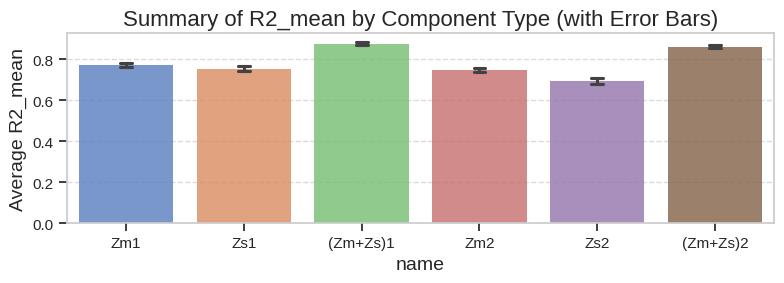


Summary of R2_mean by Component:
(Zm+Zs)1: 0.8759 ± 0.0686 / (se: 0.0028)
(Zm+Zs)2: 0.8618 ± 0.0852 / (se: 0.0035)
Zm1: 0.7727 ± 0.0883 / (se: 0.0036)
Zs1: 0.7546 ± 0.1126 / (se: 0.0046)
Zm2: 0.7472 ± 0.0882 / (se: 0.0036)
Zs2: 0.6932 ± 0.1346 / (se: 0.0056)


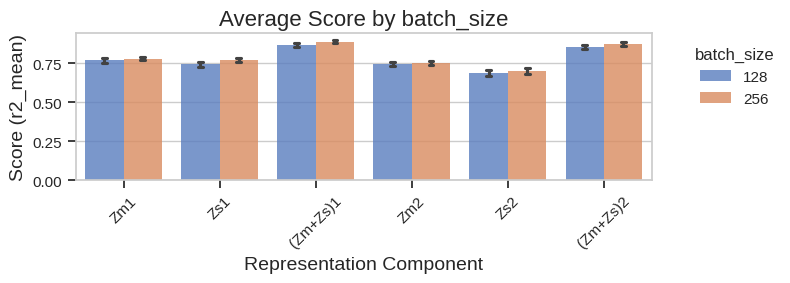

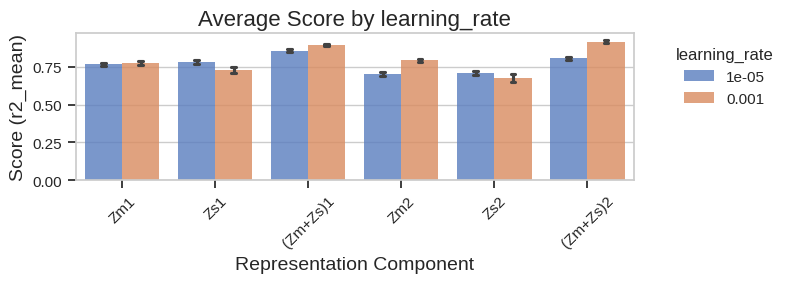

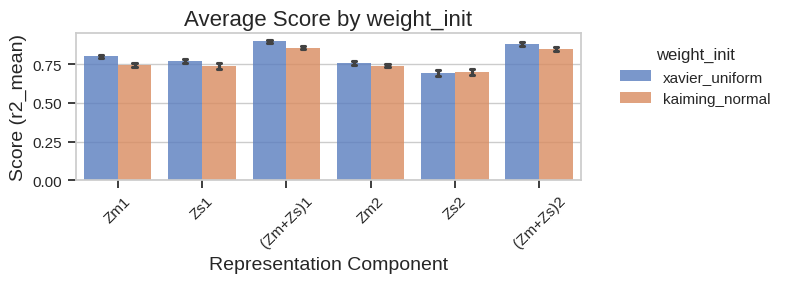

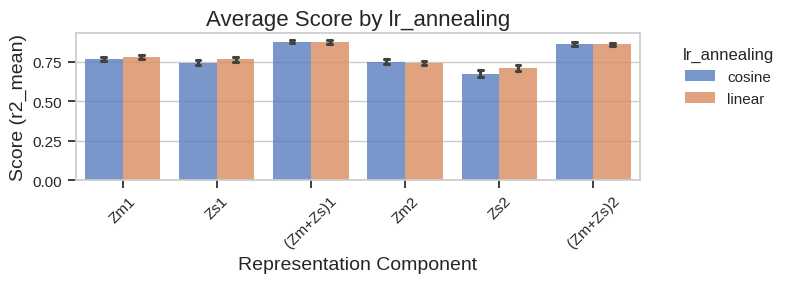

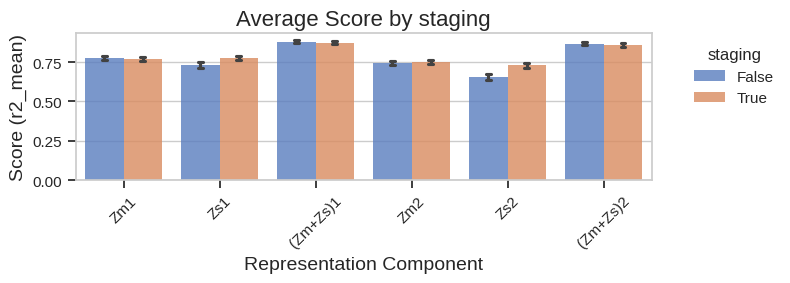

In [14]:
# plot
# Visualize regression performance by hyperparameters
# Create a summary bar plot of regression metrics by component type with error bars
if regression_df is not None:
    #metrics = ['r2_mean', 'r2_std', 'mae_mean', 'mae_std']
    metrics = ['r2_mean']
    available_metrics = [m for m in metrics if m in regression_df.columns]
    
    for metric in available_metrics:
        plt.figure(figsize=(8, 3))
        
        # Group by component name and compute mean and std
        summary_data = regression_df.groupby('name')[metric].agg(['mean', 'std']).reset_index()
        
        # Sort by mean score for better visualization
        summary_data = summary_data.sort_values('mean', ascending=False)
        
        sns.barplot(x='name', y=metric, data=regression_df, errorbar='se', palette='muted', capsize=0.1, alpha=0.8)
        
        plt.title(f'Summary of {metric.capitalize()} by Component Type (with Error Bars)')
        plt.ylabel(f'Average {metric.capitalize()}')
        #plt.xticks(range(len(summary_data)), summary_data['name'], rotation=45)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
        
        # Print numerical summary
        print(f"\nSummary of {metric.capitalize()} by Component:")
        for idx, row in summary_data.iterrows():
            print(f"{row['name']}: {row['mean']:.4f} ± {row['std']:.4f} / (se: {row['std'] / np.sqrt(len(regression_df)):.4f})")

# Plot for each hyperparameter with multiple unique values
for param in hyperparams:
    plot_score_by_hyperparam(regression_df_hyperparams, param, metric='r2_mean')

In [43]:
# get the accuracies for each run (average over random seed)
#class_df_hyperparams.groupby(['name', 'batch_size', 'learning_rate', 'weight_init', 'lr_annealing', 'staging']).agg({'accuracy': ['mean', 'std']}).reset_index()
# transform this into wide format for the name
regression_df_hyperparams_wide = regression_df_hyperparams.pivot_table(index=['batch_size', 'learning_rate', 'weight_init', 'lr_annealing', 'staging', 'seed'], columns='name', values='r2_mean').reset_index()
regression_df_report = regression_df_hyperparams_wide.groupby(['batch_size', 'learning_rate', 'weight_init', 'lr_annealing', 'staging']).agg(['mean', 'std']).reset_index()
# through out columns name and seed
regression_df_report.columns = ['_'.join(col).strip() if col[1] != '' else col[0] for col in regression_df_report.columns.values]
regression_df_report = regression_df_report.drop(columns=['seed_mean', 'seed_std'])
# for each row add whether Zm1_mean is greater than Zs1_mean
#regression_df_report['Zs1_greater_Zm1'] = regression_df_report['Zs1_mean'] > regression_df_report['Zm1_mean']
#regression_df_report['Zs2_greater_Zm2'] = regression_df_report['Zs2_mean'] > regression_df_report['Zm2_mean']
#regression_df_report['Zs1_greater_Zm2'] = regression_df_report['Zs1_mean'] > regression_df_report['Zm2_mean']
#regression_df_report['Zs2_greater_Zm1'] = regression_df_report['Zs2_mean'] > regression_df_report['Zm1_mean']
#regression_df_report['Zs_greater_Zm'] = regression_df_report['Zs1_greater_Zm1'] & regression_df_report['Zs2_greater_Zm2'] & regression_df_report['Zs1_greater_Zm2'] & regression_df_report['Zs2_greater_Zm1']
# save the report to a csv file
regression_df_report.to_csv(out_dir + '_regression_report.csv', index=False)

## Correlation and ranks

In [15]:
hyperparams = hyperparams_df.columns[:-2].tolist()
hyperparams = [hp for hp in hyperparams if len(train_df_hyperparams[hp].unique()) > 1]
hyperparams = [hp for hp in hyperparams if hp not in ['model_number', 'run_iter']]

corr_dfs_hyperparams = []
for run_iter in train_df['run_iter'].unique():
    # get the hyperparams for this run_iter
    hyperparams_run_iter = hyperparams_df[hyperparams_df['model_number'] == run_iter].iloc[0][hyperparams].to_dict()
    # add the hyperparams to the correlation data
    corr_dfs_hyperparams.append(rank_df[rank_df['run_iter'] == run_iter].assign(**hyperparams_run_iter))
corr_df_hyperparams = pd.concat(corr_dfs_hyperparams, ignore_index=True)
# filter the hyperparams to only those with more than 1 unique value
hyperparams = [hp for hp in hyperparams if len(corr_df_hyperparams[hp].unique()) > 1]
display(corr_df_hyperparams.head())

,name,metric,value,run_iter,seed,source_file,batch_size,learning_rate,weight_init,lr_annealing,staging
0,R_s-R_m1,correlation,0.083072,0,0,sim_sweep3_seed0_analysis.csv,128,0.00001,xavier_uniform,cosine,True
1,R_s-R_m2,correlation,-0.001943,0,0,sim_sweep3_seed0_analysis.csv,128,0.00001,xavier_uniform,cosine,True
2,R_m1-R_m2,correlation,-0.200048,0,0,sim_sweep3_seed0_analysis.csv,128,0.00001,xavier_uniform,cosine,True
3,R_s,rank,4.000000,0,0,sim_sweep3_seed0_analysis.csv,128,0.00001,xavier_uniform,cosine,True
4,R_m1,rank,4.000000,0,0,sim_sweep3_seed0_analysis.csv,128,0.00001,xavier_uniform,cosine,True


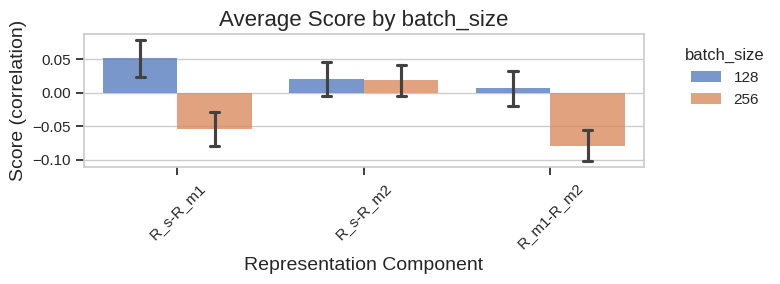

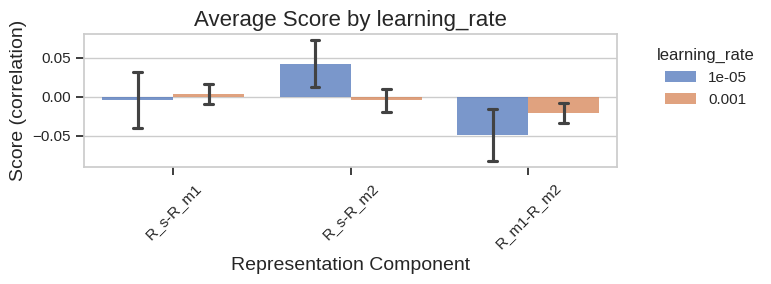

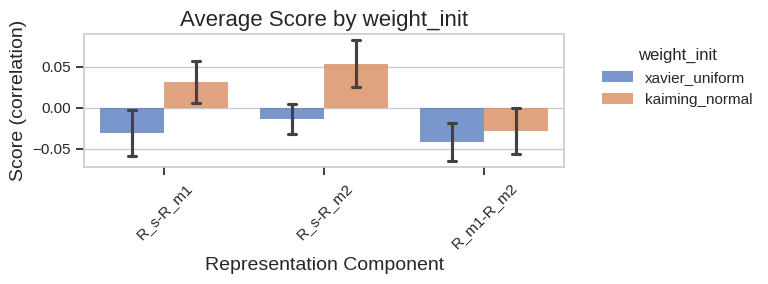

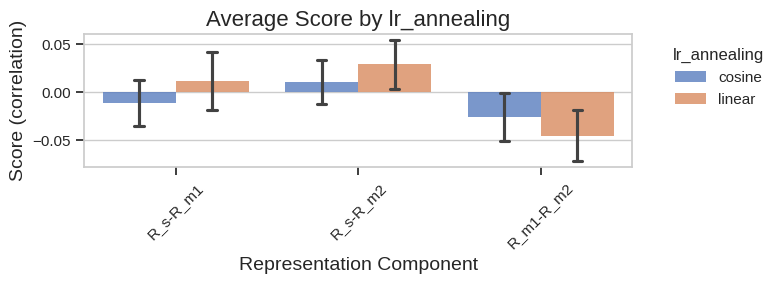

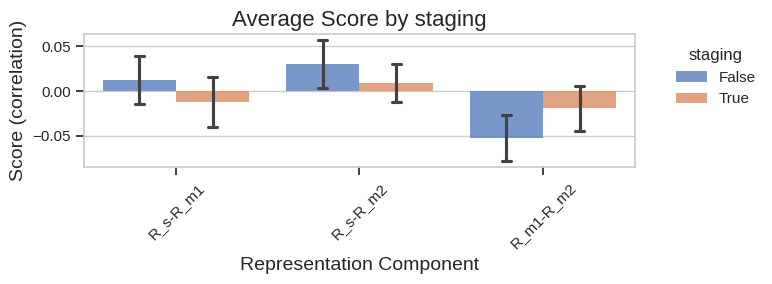

In [16]:
# plot correlation
# Visualize correlation performance by hyperparameters
for param in hyperparams:
    plot_score_by_hyperparam(corr_df_hyperparams, param, metric='correlation', metric_type='value')

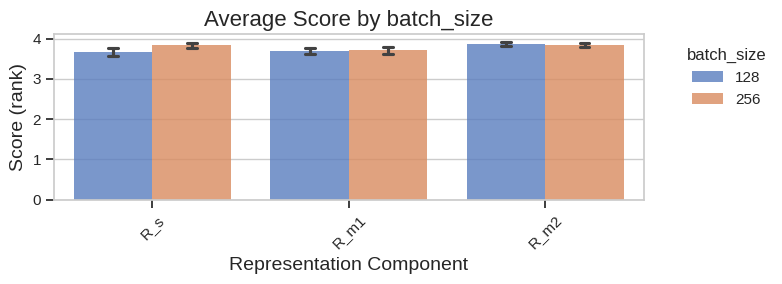

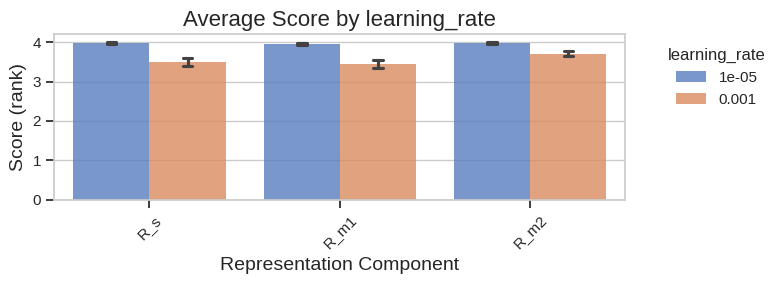

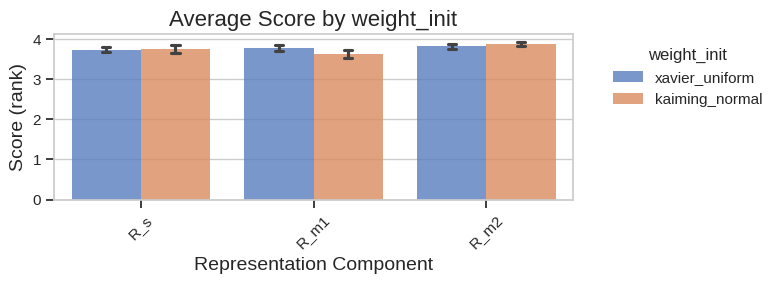

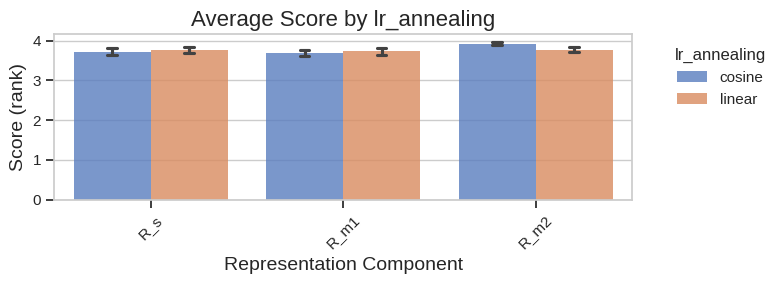

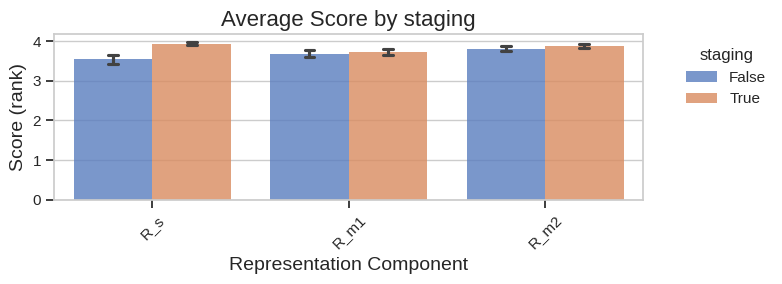

In [17]:
for param in hyperparams:
    plot_score_by_hyperparam(corr_df_hyperparams, param, metric='rank', metric_type='value')